# DCT Laboratory — Volume II, Chapter 5
## Dynamic Enterprise Optimization
**Seed `26205`** · Companion to the chapter and AXIOM Module **AXIOM-05 (Vol. II)**

The clock becomes load-bearing. Three instruments: the **invest-then-harvest
switching family** (neither myopia nor maximal patience wins — the optimum
switches at $m^* = 1$), **policy versus plan under a mid-course shock** (the
adaptive rule recovers +1.75 the blind plan cannot), and the **trajectory-space
equivalence check** — all 64 binary control sequences enumerated, confirming
the switch structure is truly optimal. Mirrored in `DCT_V2_Ch05_Lab.xlsx`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=110

import numpy as np
SEED = 26205
K0, BUDGET, N = 4.0, 3.0, 6
# Panel 1: switch family — invest fully for m periods, then consume fully
def J_switch(m):
    return 3.0*(N-m)*np.sqrt(K0+3.0*m)
# Panel 2: shock at start of period 3 (K -= 2); payoff each period = c*sqrt(K)
SHOCK_T, SHOCK = 1, 3.0
def run(policy, shock=True):
    K, J = K0, 0.0
    for k in range(N):
        if shock and k == SHOCK_T: K -= SHOCK
        i = policy(k, K); i = min(max(i, 0.0), BUDGET)
        J += (BUDGET-i)*np.sqrt(K)
        K = K + i
    return J, K
open_loop = lambda k, K: 3.0 if k == 0 else 0.0        # the no-shock optimum, replayed blind
# adaptive: re-decide each period with the state it sees — invest iff one more
# build period beats consuming now, over the remaining horizon
def feedback(k, K):
    T = N - k
    return 3.0 if (T-1)*np.sqrt(K+3.0) > T*np.sqrt(K) else 0.0
# Panel 3: all 64 binary sequences (i in {0, 3})
def enumerate_binary():
    best, arg = -1.0, None
    for b in range(2**N):
        bits = [(b >> k) & 1 for k in range(N)]
        K, J = K0, 0.0
        for k in range(N):
            i = 3.0*bits[k]
            J += (BUDGET-i)*np.sqrt(K)
            K += i
        if J > best: best, arg = J, bits
    return best, arg

def reference_values():
    Js = [J_switch(m) for m in range(N+1)]
    m_star = int(np.argmax(Js))
    Jo, Ko = run(open_loop);  Jf, Kf = run(feedback)
    Jb, bits = enumerate_binary()
    return {
        "J_myopic": round(J_switch(0),4),
        "m_star": m_star, "J_star": round(max(Js),4),
        "gap_vs_myopic": round(max(Js)-J_switch(0),4),
        "J_open_shock": round(Jo,4), "J_feedback_shock": round(Jf,4),
        "feedback_advantage": round(Jf-Jo,4),
        "K_end_adaptive": round(Kf,4),
        "binary_best": round(Jb,4),
        "binary_equals_mstar": int(abs(Jb-max(Js))<1e-9),
    }
if __name__ == "__main__":
    [print(f"{k:20s} {v}") for k,v in reference_values().items()]

J_myopic             36.0
m_star               1
J_star               39.6863
gap_vs_myopic        3.6863
J_open_shock         30.0
J_feedback_shock     31.749
feedback_advantage   1.749
K_end_adaptive       7.0
binary_best          39.6863
binary_equals_mstar  1


## Panel 1 — Intertemporal trade-offs: the switch family
Six periods, budget 3 each: invest (build $K$) or consume (earn $c\sqrt{K}$).
The family: invest fully for $m$ periods, harvest after — $J(m) = 3(6-m)\sqrt{4+3m}$.
Myopia ($m = 0$) earns 36; maximal patience ($m = 5$) earns 26. The optimum is
**$m^* = 1$: J = 39.69** — Intertemporal Trade-Offs Influence Enterprise
Optimization Outcomes (Prop.), with the trade-off's interior visible: one
period of sacrifice raises every later period's base.

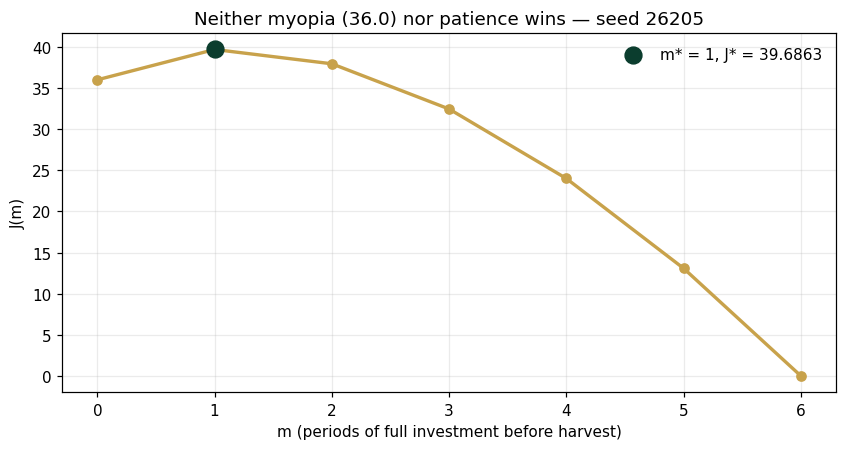

gap over the myopic policy: 3.6863


In [2]:
ms = np.arange(0, N+1)
Js = [J_switch(m) for m in ms]
fig, ax = plt.subplots(figsize=(7.8,4.2))
ax.plot(ms, Js, "o-", c="#C8A24B", lw=2.2, ms=6)
ax.scatter([np.argmax(Js)],[max(Js)], c="#0B3D2E", s=120, zorder=5, label=f"m* = {int(np.argmax(Js))}, J* = {max(Js):.4f}")
ax.set(xlabel="m (periods of full investment before harvest)", ylabel="J(m)",
       title="Neither myopia (36.0) nor patience wins — seed 26205")
ax.legend(frameon=False); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"gap over the myopic policy: {max(Js)-J_switch(0):.4f}")

## Panel 2 — Policy versus plan: the shock test
Both start with the optimal no-shock decision (invest at $k = 0$). At $k = 1$ a
shock erases the build ($K: 7 \to 4$). The **open-loop plan** replays its
schedule blind and earns 30.00. The **adaptive policy** — re-deciding each
period with the state it actually sees — rebuilds for one period and earns
**31.75**. Optimal Enterprise Decisions Depend upon Future Enterprise States
(Prop.); Enterprise Policies Determine Enterprise Trajectories (Prop.) — and a
policy that reads the state beats a plan that remembers one.

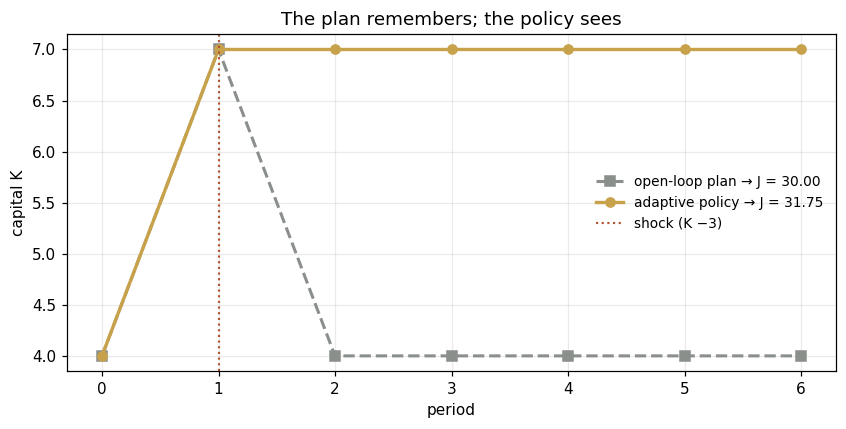

adaptive advantage under the shock: +1.7490


In [3]:
Jo, Ko = run(open_loop); Jf, Kf = run(feedback)
def trace(policy):
    K, path = K0, [K0]
    for k in range(N):
        Kk = K - (SHOCK if k == SHOCK_T else 0)
        i = min(max(policy(k, Kk), 0), BUDGET)
        K = Kk + i; path.append(K)
    return path
fig, ax = plt.subplots(figsize=(7.8,4.0))
ax.plot(trace(open_loop), "s--", c="#8A8F8B", lw=2, label=f"open-loop plan → J = {Jo:.2f}")
ax.plot(trace(feedback), "o-", c="#C8A24B", lw=2.2, label=f"adaptive policy → J = {Jf:.2f}")
ax.axvline(SHOCK_T, c="#B0532F", ls=":", lw=1.4, label="shock (K −3)")
ax.set(xlabel="period", ylabel="capital K", title="The plan remembers; the policy sees")
ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.25); plt.tight_layout(); plt.show()
print(f"adaptive advantage under the shock: {Jf-Jo:+.4f}")

## Panel 3 — The equivalence check: all 64 sequences
The Dynamic Enterprise Optimization Equivalence Theorem licenses solving in
trajectory space. Executed literally: every binary control sequence
($i_k \in \{0, 3\}$, $2^6 = 64$ of them) evaluated. The best is **39.6863 —
exactly $J(m^*)$**, and its bit pattern is `100000`: the switch structure is
not a convenient family, it is the global optimum over the full sequence space.

In [4]:
Jb, bits = enumerate_binary()
print(f"best over all 64 binary sequences: {Jb:.4f}")
print(f"optimal bit pattern (1 = invest): {''.join(str(b) for b in bits)}")
print(f"equals the switch-family optimum: {abs(Jb-max(J_switch(m) for m in range(N+1)))<1e-9}")

best over all 64 binary sequences: 39.6863
optimal bit pattern (1 = invest): 100000
equals the switch-family optimum: True


## Validation — agrees with `DCT_V2_Ch05_Lab.xlsx`

In [5]:
ref = reference_values()
expected = {"J_myopic":36.0,"m_star":1,"J_star":39.6863,"gap_vs_myopic":3.6863,
 "J_open_shock":30.0,"J_feedback_shock":31.749,"feedback_advantage":1.749,
 "K_end_adaptive":7.0,"binary_best":39.6863,"binary_equals_mstar":1}
for k,v in expected.items():
    assert abs(ref[k]-v)<5e-4, f"MISMATCH {k}"
    print(f"PASS  {k:20s} {ref[k]}")
print("\nAll checkpoints agree — seed 26205.")

PASS  J_myopic             36.0
PASS  m_star               1
PASS  J_star               39.6863
PASS  gap_vs_myopic        3.6863
PASS  J_open_shock         30.0
PASS  J_feedback_shock     31.749
PASS  feedback_advantage   1.749
PASS  K_end_adaptive       7.0
PASS  binary_best          39.6863
PASS  binary_equals_mstar  1

All checkpoints agree — seed 26205.


**Next**: Exercises 5.5–5.9 (Part C) vary the shock's timing and watch adaptation's value appear and vanish; AXIOM-05's trajectory theater animates the 64 sequences. Chapter 6 gives the switch structure its theory: Pontryagin. Solutions: IM Vol. II, Ch. 5.